# Human in the loop w LangGraph

**Human in the loop** (HITL) to wzorzec, w którym wykonanie grafu jest przerywane w określonym miejscu, aby człowiek mógł dostarczyć dane, zatwierdzić decyzję lub zmienić kierunek.

| | Pełna automatyzacja | Human in the loop |
|---|---|---|
| **Przebieg** | end-to-end bez przerw | zatrzymuje się i czeka na człowieka |
| **Dane wejściowe** | tylko na starcie | pojawiają się w trakcie pętli |
| **Wznawianie** | nie dotyczy | `Command(resume=wartość)` |

Kluczowy mechanizm to `interrupt()` – wywołanie go wewnątrz node'a zatrzymuje graf i przekazuje sterowanie z powrotem do wywołującego. Graf musi być skompilowany z checkpointerem, żeby wiedział gdzie wznowić wykonanie.

Przykład: interaktywna historia tworzona naprzemiennie przez AI i człowieka. Faza setup → AI pyta o parametry historii → człowiek odpowiada → pętla narracji. Wyjście należy wyłącznie do człowieka: wpisanie `"koniec"` powoduje że AI zamyka historię i pętla kończy się.

---

Pipeline ma siedem node'ów podzielonych na dwie fazy:

**Faza setup (jednorazowa):**

1. **`gather_info`** – LLM pyta o miejsce akcji, bohatera, opis i cel historii
2. **`human_answers`** – `interrupt()` czeka na odpowiedź człowieka
3. **`parse_info`** – LLM wyciąga strukturyzowane dane z wiadomości użytkownika

**Faza narracji (pętla):**

4. **`ai_narrates`** – LLM pisze kolejny fragment historii
5. **`human_continues`** – człowiek kontynuuje historię
6. **`check_human_goal`** – LLM sprawdza czy cel został osiągnięty
7. **`ai_closing`** – uruchamia się gdy człowiek wpisze `"koniec"` lub gdy osiągnie założony cel

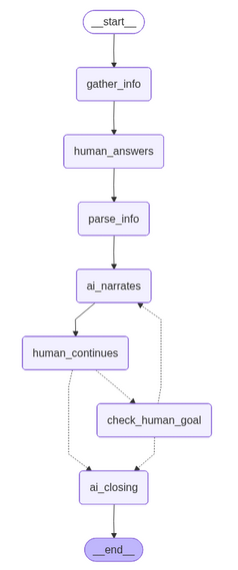

In [4]:
from dotenv import load_dotenv

load_dotenv()

True

## State

- **`setup_description`** – surowa odpowiedź człowieka z fazy przygotowania (plain string)
- **`setup_structured`** – parametry historii wyekstrahowane z setupu (miejsce, bohater, opis, cel)
- **`story_messages`** – wiadomości narracyjne; reducer `add_messages` dołącza nowe bez nadpisywania
- **`goal_reached`** – flaga czy cel historii został osiągnięty

In [5]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages


class State(TypedDict):
    setup_description: str
    setup_structured: dict
    story_messages: Annotated[list, add_messages]
    goal_reached: bool
    story_options: list[str]

## Checkpointer

`interrupt()` wymaga checkpointera – obiektu zapisującego stan po każdym kroku. Dzięki temu LangGraph wie, gdzie wznowić wykonanie po dostarczeniu odpowiedzi przez człowieka.

In [6]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

## Structured output

Node `parse_info` będzie generował ustrukturyzowane wyjście – wyciąga on cztery informacje z wiadomości użytkownika na temat szczegółów historii. Pozostałe node'y generują swobodny tekst i nie wymagają Pydantic.

In [7]:
from pydantic import BaseModel, Field


class StoryInfo(BaseModel):
    setting: str = Field(description="Miejsce i czas akcji historii")
    hero: str = Field(description="Imię głównego bohatera")
    description: str = Field(description="Ogólny opis sytuacji i tło fabularne")
    goal: str = Field(description="Cel lub zakończenie, do którego zmierza historia")


class GoalCheck(BaseModel):
    goal_reached: bool = Field(description="Czy fragment historii osiąga jej cel")


class NarrativeWithOptions(BaseModel):
    narrative: str = Field(description="Kolejny fragment historii (3-5 zdań)")
    options: list[str] = Field(
        description="Lista 2-4 krótkich propozycji kontynuacji dla użytkownika. "
                    "Opcje powinny być różnorodne: np. odważna akcja, ostrożne wycofanie, eksploracja, rozmowa.",
        min_length=2,
        max_length=4,
    )

## Implementacja node'ów

In [8]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.types import interrupt

In [9]:
debug = True

GATHER_PROMPT = (
    "Zanim zaczniemy, potrzebuję kilku informacji:\n"
    "  1. Miejsce i czas akcji\n"
    "  2. Imię głównego bohatera\n"
    "  3. Ogólny opis sytuacji i tło fabularne\n"
    "  4. Cel historii – co powinno się wydarzyć na końcu\n\n"
    "Podaj wszystkie cztery informacje w jednej wiadomości."
)

In [10]:
def gather_info_node(state: State):
    if debug:
        print("Node: gather_info\n")

    print(f"\nAI: {GATHER_PROMPT}\n")
    return {}


def human_answers_node(state: State):
    if debug:
        print("Node: human_answers | oczekiwanie na odpowiedź...\n")

    user_text = interrupt("Twoje odpowiedzi: ")
    return {"setup_description": user_text}


def parse_info_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: parse_info")

    model_name = config.get("configurable", {}).get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0).with_structured_output(StoryInfo)

    info: StoryInfo = llm.invoke([
        HumanMessage(content=state["setup_description"]),
        HumanMessage(content="Wyciągnij parametry historii: miejsce akcji, bohatera, opis i cel."),
    ])

    if debug:
        print(f"  Miejsce:  {info.setting}")
        print(f"  Bohater:  {info.hero}")
        print(f"  Opis:     {info.description}")
        print(f"  Cel:      {info.goal}")
        print()

    return {"setup_structured": info.model_dump()}

In [11]:
def ai_narrates_node(state: State, config: RunnableConfig):
    if debug:
        print(f"Node: ai_narrates | fragmenty narracji: {len(state['story_messages'])}\n")

    model_name = config.get("configurable", {}).get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0.8, max_tokens=8000).with_structured_output(NarrativeWithOptions)

    info = state["setup_structured"]
    system = SystemMessage(
        content=(
            f"Piszesz interaktywną historię naprzemiennie z użytkownikiem. "
            f"Miejsce akcji: {info['setting']}. Bohater: {info['hero']}. "
            f"Tło: {info['description']}. Cel historii: {info['goal']}. "
            f"Napisz kolejny fragment historii (3-5 zdań) oraz zaproponuj 2-4 krótkie opcje kontynuacji dla użytkownika."
        )
    )
    result: NarrativeWithOptions = llm.invoke([system] + state["story_messages"])

    return {
        "story_messages": [AIMessage(content=result.narrative)],
        "story_options": result.options,
    }


def human_continues_node(state: State):
    if debug:
        print("Node: human_continues | oczekiwanie na kontynuację...\n")

    options = state.get("story_options", [])
    user_input: str = interrupt("Twój wybór: ")

    stripped = user_input.strip()
    if stripped.isdigit():
        idx = int(stripped) - 1
        chosen = options[idx] if 0 <= idx < len(options) else user_input
    else:
        chosen = user_input

    return {"story_messages": [HumanMessage(content=chosen)]}


def check_human_goal_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: check_human_goal\n")

    model_name = config.get("configurable", {}).get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0).with_structured_output(GoalCheck)

    goal = state["setup_structured"]["goal"]
    last_human_message = state["story_messages"][-1].content

    check: GoalCheck = llm.invoke([
        SystemMessage(content=f"Cel historii: {goal}"),
        HumanMessage(content=f"Czy poniższy fragment historii osiąga ten cel?\n\n'{last_human_message}'"),
    ])
    return {"goal_reached": check.goal_reached}


def ai_closing_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: ai_closing\n")

    model_name = config.get("configurable", {}).get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0.7)

    info = state["setup_structured"]
    system = SystemMessage(
        content=(
            f"Pisałeś interaktywną historię razem z użytkownikiem. "
            f"Cel historii był: {info['goal']}. "
            f"Użytkownik zdecydował się zakończyć historię. "
            f"Napisz krótkie zamknięcie (2-3 zdania) – podsumuj jak potoczyła się historia."
        )
    )
    response = llm.invoke([system] + state["story_messages"])
    return {"story_messages": [response]}

## Sprawdzanie warunków

W pipelinie mamy dwa warunkowe przejścia:

**Po `human_continues`:**
- `"koniec"` → `ai_closing` (AI zamyka historię, potem `END`)
- cokolwiek innego → `check_human_goal` (sprawdzenie czy cel osiągnięty)

**Po `check_human_goal`:**
- cel osiągnięty → `ai_closing`
- cel nie osiągnięty → `ai_narrates` (kolejna runda)

In [12]:
def after_human(state: State) -> str:
    last = state["story_messages"][-1].content.strip().lower()
    if last == "koniec":
        if debug:
            print("IF routing: 'koniec' -> ai_closing\n")
        return "ai_closing"
    if debug:
        print("IF routing: sprawdzam cel -> check_human_goal\n")
    return "check_human_goal"


def after_check(state: State) -> str:
    if state["goal_reached"]:
        if debug:
            print("IF routing: cel osiągnięty -> ai_closing\n")
        return "ai_closing"
    if debug:
        print("IF routing: kontynuacja -> ai_narrates\n")
    return "ai_narrates"

## State graph

Faza setup przebiega liniowo: `gather_info → human_answers → parse_info`.

Faza narracji to pętla `ai_narrates → human_continues` z dwoma warunkami wyjścia:
- użytkownik wpisuje `koniec`
- użytkownik opisuje wydarzenie, które jest celem historii

In [13]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(State)

graph.add_node("gather_info", gather_info_node)
graph.add_node("human_answers", human_answers_node)
graph.add_node("parse_info", parse_info_node)
graph.add_node("ai_narrates", ai_narrates_node)
graph.add_node("human_continues", human_continues_node)
graph.add_node("check_human_goal", check_human_goal_node)
graph.add_node("ai_closing", ai_closing_node)

graph.add_edge(START, "gather_info")
graph.add_edge("gather_info", "human_answers")
graph.add_edge("human_answers", "parse_info")
graph.add_edge("parse_info", "ai_narrates")
graph.add_edge("ai_narrates", "human_continues")
graph.add_conditional_edges("human_continues", after_human, {"check_human_goal": "check_human_goal", "ai_closing": "ai_closing"})
graph.add_conditional_edges("check_human_goal", after_check, {"ai_narrates": "ai_narrates", "ai_closing": "ai_closing"})
graph.add_edge("ai_closing", END)

pipeline = graph.compile(checkpointer=checkpointer)

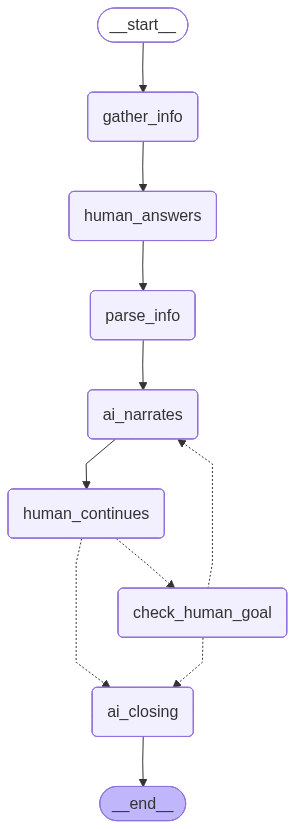

In [14]:
from IPython.display import Image, display

display(Image(pipeline.get_graph().draw_mermaid_png(), width=150))

# pipeline

## Uruchomienie

In [15]:
import json
from langchain_core.messages import BaseMessage


def save_state_to_json(state_values: dict, filepath: str = "story_state.json") -> None:
    def serialize_message(msg: BaseMessage) -> dict:
        return {"type": msg.type, "content": msg.content}

    serializable = {
        **state_values,
        "story_messages": [serialize_message(m) for m in state_values.get("story_messages", [])],
    }
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(serializable, f, ensure_ascii=False, indent=2)

In [16]:
from langgraph.types import Command

INITIAL_STATE = {
    "setup_description": "",
    "setup_structured": {},
    "story_messages": [],
    "goal_reached": False,
    "story_options": [],
}

state_evolution = []

In [17]:
def run_story_interactive(config: dict):
    pipeline.invoke(INITIAL_STATE, config=config)
    shown_count = 0

    while True:
        state = pipeline.get_state(config)
        state_values = state.values
        story_msgs = state_values.get("story_messages", [])

        for msg in story_msgs[shown_count:]:
            if msg.type == "ai":
                print(f"\nAI: {msg.content}\n")
        shown_count = len(story_msgs)

        if not state.next:
            print("[Koniec historii]")
            save_state_to_json(state_values)
            break

        options = state_values.get("story_options", [])
        if options:
            print("Możliwe kontynuacje:")
            for i, opt in enumerate(options, 1):
                print(f"  {i}. {opt}")
            print("  (lub wpisz własną kontynuację / 'koniec' aby zakończyć)\n")

        user_input = input("Twój wybór: ").strip()
        print()
        pipeline.invoke(Command(resume=user_input), config=config)
        save_state_to_json(pipeline.get_state(config).values)

In [18]:
interactive_config = {"configurable": {"thread_id": "historia", "model_name": "openai/gpt-4o-mini"}}
run_story_interactive(interactive_config)

Node: gather_info


AI: Zanim zaczniemy, potrzebuję kilku informacji:
  1. Miejsce i czas akcji
  2. Imię głównego bohatera
  3. Ogólny opis sytuacji i tło fabularne
  4. Cel historii – co powinno się wydarzyć na końcu

Podaj wszystkie cztery informacje w jednej wiadomości.

Node: human_answers | oczekiwanie na odpowiedź...



Twój wybór:  przystanek autobusowy godzina 13:00, imię to eloszka, eloszka zaprosił kobite na randke. Cel - kobita ma zrobić ramen 



Node: human_answers | oczekiwanie na odpowiedź...

Node: parse_info
  Miejsce:  Przystanek autobusowy, godzina 13:00
  Bohater:  Eloszka
  Opis:     Eloszka zaprosił kobietę na randkę, aby spędzić z nią czas i spróbować jej umiejętności kulinarnych.
  Cel:      Kobieta ma zrobić ramen.

Node: ai_narrates | fragmenty narracji: 0

Node: human_continues | oczekiwanie na kontynuację...


AI: Eloszka stał na przystanku autobusowym, z niecierpliwością przeglądając zegarek. Był podekscytowany, bo wkrótce miał spotkać się z Mają, kobietą, która przez ostatnie tygodnie okupowała jego myśli. Z ustami pełnymi pomysłów na idealną randkę, marzył o tym, jak udadzą się razem na zakupy, aby skompletować składniki do ramenu, a potem spędzą wieczór w jego kuchni. W tej chwili dostrzegł Maję z daleka; szła w jego kierunku z uśmiechem na twarzy, a Eloszka poczuł, jak jego serce przyspiesza.

Możliwe kontynuacje:
  1. Zaproponować Mai szybki spacer po okolicy przed zakupami.
  2. Zapytać Maję, czy ma jaki

Twój wybór:  Eloszka pyta maje czy  umie gotowac



Node: human_continues | oczekiwanie na kontynuację...

IF routing: sprawdzam cel -> check_human_goal

Node: check_human_goal

IF routing: kontynuacja -> ai_narrates

Node: ai_narrates | fragmenty narracji: 2

Node: human_continues | oczekiwanie na kontynuację...


AI: - Cześć, Maja! - zawołał Eloszka, gdy dziewczyna zbliżyła się do niego. - Czy umiesz gotować? Mówiłem, że planuję nauczyć się robić ramen, a chciałbym, żebyś mi w tym pomogła.

Maja zaśmiała się lekko, kręcąc głową. - Gotować? Cóż, mam kilka sekretów, które mogę ci przekazać, ale to nie znaczy, że jestem szefem kuchni. Chcesz spróbować? - spytała z błyskiem w oku.

Eloszka czuł, że atmosfera staje się coraz bardziej swobodna i przyjemna. Może ten wieczór naprawdę się uda!

Możliwe kontynuacje:
  1. Zaproponować Maji, żeby to ona gotowała ramen samodzielnie.
  2. Podzielić się swoimi doświadczeniami z gotowaniem i zapytać o jej ulubione potrawy.
  3. Zaproponować, że pójdą na zakupy po składniki do ramenu.
  4. Zacząć opo

Twój wybór:  3



Node: human_continues | oczekiwanie na kontynuację...

IF routing: sprawdzam cel -> check_human_goal

Node: check_human_goal

IF routing: cel osiągnięty -> ai_closing

Node: ai_closing


AI: - W takim razie, co powiesz na to, żebyśmy poszli na zakupy po składniki do ramenu? - zaproponował Eloszka, z entuzjazmem patrząc na Maję. - Myślę, że razem znajdziemy wszystko, co nam potrzebne, a przy okazji będziemy mieli okazję lepiej się poznać.

Maja uśmiechnęła się szeroko. - To świetny pomysł! Znam kilka miejsc, gdzie można znaleźć świeże produkty. Chodźmy! - odpowiedziała, a oboje ruszyli w stronę pobliskiego targu, rozmawiając i śmiejąc się, ciesząc się wspólnym czasem.

[Koniec historii]


> **ZADANIA**